1. Bollinger BandsBollinger Bands define a volatility-adjusted range around a price series. The model assumes that price is a stochastic process $P_t$ whose local mean and variance can be estimated via a rolling window of length $n$.DefinitionThe bands consist of three lines:Middle Band: A simple moving average (SMA) of the price.$$SMA_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$Upper and Lower Bands: The SMA shifted by $k$ standard deviations ($\sigma_t$).$$Upper_t = SMA_t + k \cdot \sigma_t$$ $$Lower_t = SMA_t - k \cdot \sigma_t$$where the rolling standard deviation is:$$\sigma_t = \sqrt{\frac{1}{n} \sum_{i=0}^{n-1} (P_{t-i} - SMA_t)^2}$$

2. CUSUM FilterThe Cumulative Sum (CUSUM) filter is a change-point detection method designed to identify a shift in the mean of a series. In quantitative finance, specifically within the framework of "Advances in Financial Machine Learning" (López de Prado), it is used to sample events only when the cumulative deviation of returns exceeds a threshold.DefinitionGiven a series of observed returns $r_t$, we want to detect when the cumulative divergence from a expected value (often zero in high-frequency contexts) exceeds a threshold $h$. We track two processes, $S^+_t$ (for positive shifts) and $S^-_t$ (for negative shifts):$$S^+_t = \max(0, S^+_{t-1} + r_t - E[r_t])$$ $$S^-_t = \min(0, S^-_{t-1} + r_t - E[r_t])$$A "filter hit" or event is triggered at time $t$ if:$$S^+_t > h \quad \text{or} \quad S^-_t < -h$$Upon a trigger, the corresponding sum is reset to 0.

1. Structural Divergence: Integration vs. WindowingBollinger Bands operate in Chronological Time. They assume that the recent past (the window $n$) is a sufficient proxy for the current distribution. The signal is triggered by a point-in-time violation of a local volatility boundary:$$P_t > \mu_{n,t} + k\sigma_{n,t}$$This is essentially a "memoryless" thresholding of a low-pass filter. It ignores the path taken to reach $P_t$.CUSUM Filters operate in Information Time. They treat price as a stochastic process where signals are generated by the accumulation of evidence. You are not looking for a price level; you are looking for a structural shift in the mean of the returns $r_t$. The filter tracks the cumulative deviation:$$S^+_t = \max(0, S^+_{t-1} + r_t - E[r_t])$$A trigger occurs only when the integral of the returns exceeds a threshold $h$.

2. Why CUSUM Reduces the Standard Deviation of ReturnsThe prompt notes that CUSUM-sampled returns exhibit lower standard deviation and lower absolute returns compared to fixed-time or band-based sampling. This is not a bug; it is the mechanism's primary virtue.A. Filtering the "Churn" of Microstructure NoiseIn chronological sampling (or Bollinger Bands), you are forced to observe the market at intervals (or touches) regardless of whether information has arrived. Much of this movement is "noise"—bid-ask bounce, small liquidity imbalances, or random walk fluctuations. These contribute to the variance of your returns without offering predictive signal.CUSUM stretches time during low-activity periods and compresses it during high-volatility events. By requiring a total accumulated deviation of $h$, you effectively act as a high-pass filter that discards any move that hasn't achieved a "quantum" of informational significance.B. Homogeneity of SamplesBollinger Bands are notorious for "walking the bands." In a strong trend, the standard deviation $\sigma$ expands, and the price can stay pinned to the upper band for extended periods. The returns sampled at these "touches" are highly heterogeneous—some represent tiny fluctuations in a high-volatility regime, others represent massive breakouts.CUSUM-sampled returns are, by construction, more stationary. Because every sample is triggered by the same threshold $h$, the "distance" traveled by the price between triggers is structurally constrained. This leads to a return distribution with thinner tails (less kurtosis) and lower variance.

3. Why It Matters: The ML and Statistical RealityIf you are training a model or building a strategy, variance is your enemy for three reasons:Label Stability: In Machine Learning, if your features ($X$) lead to labels ($y$) with massive variance, the signal-to-noise ratio is too low for the optimizer to find a global minimum. CUSUM produces labels that are "packets of information" of roughly equal magnitude, making the mapping $X \to y$ much more tractable.Avoidance of Overfitting: Bollinger Bands are highly sensitive to the window $n$. If $n$ is too small, you overfit to noise; if too large, you lag the regime shift. CUSUM's threshold $h$ is a structural parameter that relates to the "cost" of information. It is more robust to regime shifts because it doesn't care when the move happened, only that it did happen.Transaction Cost Efficiency: Trading every Bollinger Band touch in a choppy market is a recipe for death by a thousand commissions. CUSUM forces a "wait-and-see" posture. It ensures that the expected move is large enough to justify the bid-ask spread and slippage.

In [30]:
import pandas as pd

data = pd.read_csv(r'G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv')
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [77]:
#Create a CUSUM filter
def cusum_filter(data, threshold):
    data['returns'] = data['Close'].pct_change()
    data['cusum_pos'] = 0.0
    data['cusum_neg'] = 0.0
    events = []
    
    for i in range(1, len(data)):
        data.at[i, 'cusum_pos'] = max(0, data.at[i-1, 'cusum_pos'] + data.at[i, 'returns'])
        data.at[i, 'cusum_neg'] = min(0, data.at[i-1, 'cusum_neg'] + data.at[i, 'returns'])
        
        if data.at[i, 'cusum_pos'] > threshold:
            print(f"Positive CUSUM signal at index {i}, timestamp: {data.at[i, 'timestamp']}")
            events.append(i)
            data.at[i, 'cusum_pos'], data.at[i, 'cusum_neg'] = 0, 0  # Reset after signal
            
        if data.at[i, 'cusum_neg'] < -threshold:
            print(f"Negative CUSUM signal at index {i}, timestamp: {data.at[i, 'timestamp']}")
            events.append(i)
            data.at[i, 'cusum_pos'], data.at[i, 'cusum_neg'] = 0, 0  # Reset after signal
    return pd.DataFrame(events, columns=['index'])

def bollinger_bands(data, window=20, num_std=2):
    data['MA'] = data['Close'].rolling(window=window).mean()
    data['STD'] = data['Close'].rolling(window=window).std()
    data['UpperBand'] = data['MA'] + (data['STD'] * num_std)
    data['LowerBand'] = data['MA'] - (data['STD'] * num_std)
    return data

def bollinger_band_filter(data, window=50, num_std=2):
    # Assuming this external function populates 'UpperBand' and 'LowerBand'
    data = bollinger_bands(data, window, num_std)
    
    # Shift data by 1 to get t-1 values
    prev_close = data['Close'].shift(1)
    prev_upper = data['UpperBand'].shift(1)
    prev_lower = data['LowerBand'].shift(1)
    
    # Crossing the Upper Band from below:
    # P_{t-1} <= Upper_{t-1} AND P_t > Upper_t
    cross_upper = (prev_close <= prev_upper) & (data['Close'] > data['UpperBand'])
    
    # Crossing the Lower Band from below:
    # P_{t-1} <= Lower_{t-1} AND P_t > Lower_t
    cross_lower = (prev_close <= prev_lower) & (data['Close'] > data['LowerBand'])
    
    # Combine signals if you want to capture crossing EITHER band from below
    events_mask = cross_upper | cross_lower
    
    # Extract the DataFrame indices where the crossing occurred
    events = data[events_mask].index.tolist()
    
    # Optional: Print timestamps (avoid this in live/production loops as I/O is slow)
    # for idx in events:
    #    print(f"Crossing from below at index {idx}, timestamp: {data.loc[idx, 'timestamp']}")
        
    return pd.DataFrame(events, columns=['index'])

threshold = 0.05  # Example threshold
cusum_events = cusum_filter(data, threshold)
bollinger_events = bollinger_band_filter(data, num_std=1.5)

Positive CUSUM signal at index 50, timestamp: 2017-03-01 14:30:00
Positive CUSUM signal at index 151, timestamp: 2017-07-14 19:56:00
Positive CUSUM signal at index 203, timestamp: 2017-10-11 20:00:00
Positive CUSUM signal at index 248, timestamp: 2017-12-18 20:05:00
Positive CUSUM signal at index 271, timestamp: 2018-01-22 21:00:00
Negative CUSUM signal at index 285, timestamp: 2018-02-05 18:39:00
Negative CUSUM signal at index 295, timestamp: 2018-02-09 18:21:00
Positive CUSUM signal at index 299, timestamp: 2018-02-14 20:48:00
Negative CUSUM signal at index 321, timestamp: 2018-03-22 20:02:00
Positive CUSUM signal at index 337, timestamp: 2018-04-17 16:23:00
Positive CUSUM signal at index 352, timestamp: 2018-05-21 13:31:00
Positive CUSUM signal at index 381, timestamp: 2018-07-25 20:17:00
Negative CUSUM signal at index 418, timestamp: 2018-10-11 13:41:00
Negative CUSUM signal at index 433, timestamp: 2018-10-26 14:35:00
Positive CUSUM signal at index 442, timestamp: 2018-11-07 20:06

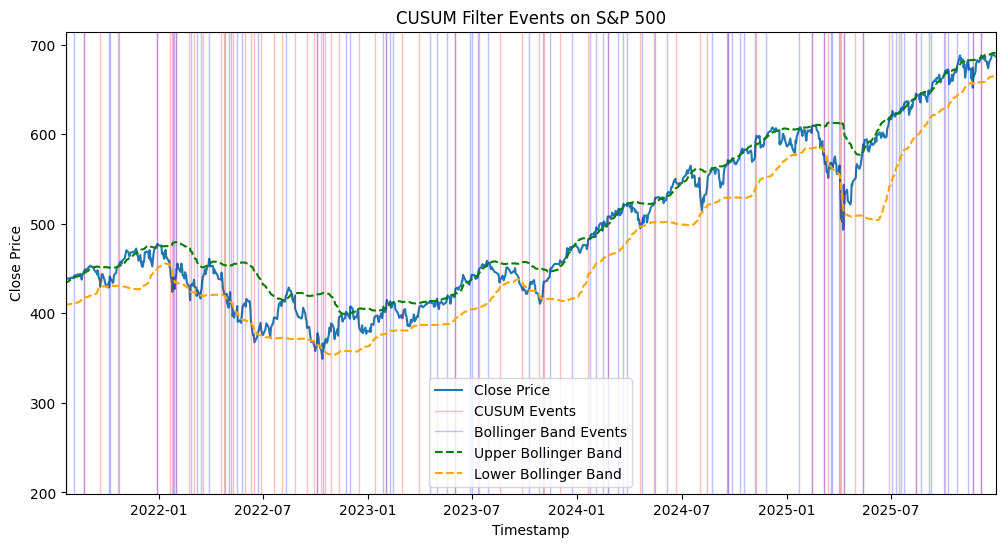

In [79]:
#Plot the the price and the events
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(data['timestamp'], data['Close'], label='Close Price')

# Show events as vertical lines instead of point markers
first_cusum_event = True
for event_index in cusum_events['index']:
    plt.axvline(
        x=data.loc[event_index, 'timestamp'],
        color='red',
        alpha=0.25,
        linewidth=1,
        label='CUSUM Events' if first_cusum_event else None,
    )
    first_cusum_event = False

first_bollinger_event = True
for event_index in bollinger_events['index']:
    plt.axvline(
        x=data.loc[event_index, 'timestamp'],
        color='blue',
        alpha=0.25,
        linewidth=1,
        label='Bollinger Band Events' if first_bollinger_event else None,
    )
    first_bollinger_event = False

#Paint bollinger bands
plt.plot(data['timestamp'], data['UpperBand'], label='Upper Bollinger Band', color='green', linestyle='--')
plt.plot(data['timestamp'], data['LowerBand'], label='Lower Bollinger Band', color='orange', linestyle='--')
plt.title('CUSUM Filter Events on S&P 500')
plt.xlim(data['timestamp'][1000], data['timestamp'].max())
plt.xlabel('Timestamp')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [78]:
#Cantidad de eventos detectados por cada filtro
print(f"Number of CUSUM events: {len(cusum_events)}")
print(f"Number of Bollinger Band events: {len(bollinger_events)}")

Number of CUSUM events: 124
Number of Bollinger Band events: 152


Lower STD of Returns: The High-Pass Filter EffectBollinger Bands (BB) generate signals based on $ P_t = \text{SMA}_t \pm k\sigma_t $. Because $\sigma_t$ is rolling, the "barrier" for a signal is constantly moving. In a low-volatility regime, the bands collapse, triggering on noise (microstructure contamination). In high-volatility regimes, the bands expand, triggering only on massive moves. This creates a return distribution with fat tails (leptokurtosis) and high variance.CUSUM, conversely, triggers when:$$ S_t = \max(0, S_{t-1} + r_t - E[r_t]) > h $$By setting a fixed (or slowly evolving) threshold $h$, you are essentially defining a "quantum" of information. You refuse to acknowledge an event until the integrated signal overcomes the cumulative noise. This acts as a high-pass filter that ignores the "churn" of the market, leading to a tighter distribution of returns around the threshold $h$.Lower STD of Absolute Returns: The Evidence of Constant InformationThis is the more critical observation. A lower standard deviation of absolute returns ($ \sigma_{|r|} $) means that every event sampled by the CUSUM filter has roughly the same "magnitude" or "informational weight."In Bollinger Bands, an "event" (a band touch) could represent a $0.5\%$ move or a $5.0\%$ move depending on the lookback window $n$. In CUSUM, an event is, by construction, a move of approximately size $h$.

In [80]:
import numpy as np
#Heteroskedasticity of each filter
cusum_prices = data.loc[cusum_events['index'], 'Close']
cusum_returns = cusum_prices.pct_change().dropna()
bollinger_prices = data.loc[bollinger_events['index'], 'Close']
bollinger_returns = bollinger_prices.pct_change().dropna()
cusum_heteroskedasticity = (cusum_returns.var())**0.5
bollinger_heteroskedasticity = (bollinger_returns.var())**0.5
print(f"Heteroskedasticity of CUSUM events: {cusum_heteroskedasticity}")
print(f"Heteroskedasticity of Bollinger Band events: {bollinger_heteroskedasticity}")

Heteroskedasticity of CUSUM events: 0.04516555513177354
Heteroskedasticity of Bollinger Band events: 0.04148633337846614


In [81]:
#Heteroskedasticity of the absolute returns 
cusum_abs_returns = abs(cusum_returns)
bollinger_abs_returns = abs(bollinger_returns)
cusum_abs_heteroskedasticity = (cusum_abs_returns.var())**0.5
bollinger_abs_heteroskedasticity = (bollinger_abs_returns.var())**0.5
print(f"Heteroskedasticity of absolute CUSUM returns: {cusum_abs_heteroskedasticity}")
print(f"Heteroskedasticity of absolute Bollinger Band returns: {bollinger_abs_heteroskedasticity}")


Heteroskedasticity of absolute CUSUM returns: 0.01591844730444182
Heteroskedasticity of absolute Bollinger Band returns: 0.03354030939234199


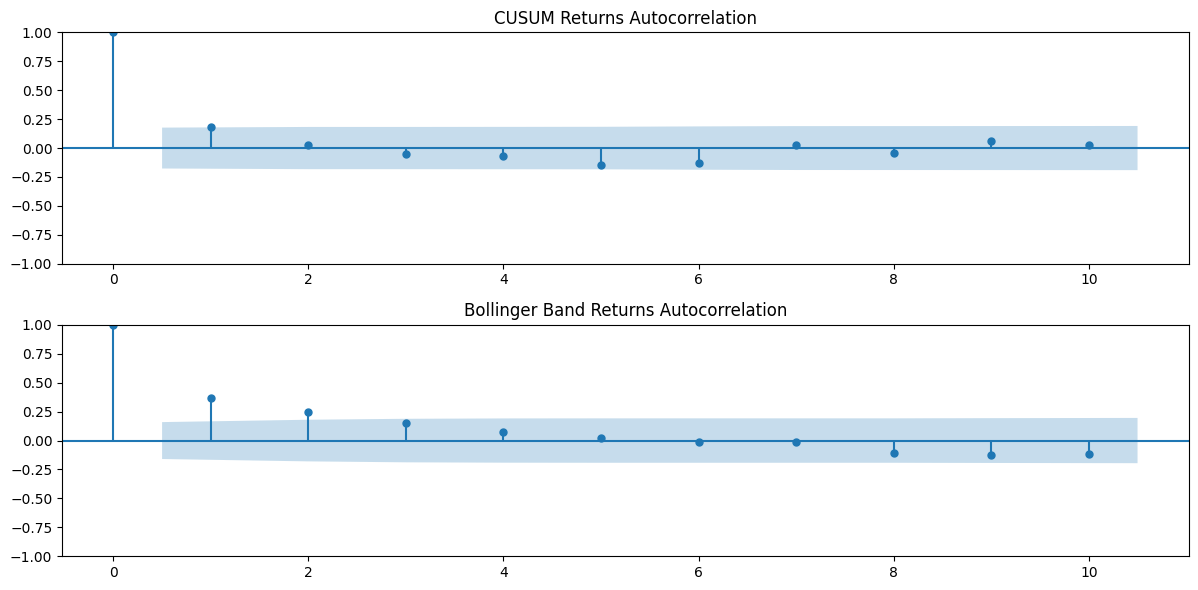

In [82]:
#Autocorrelation of returns for each filter
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plot_acf(abs(cusum_returns), lags=10, ax=plt.gca(), title='CUSUM Returns Autocorrelation')
plt.subplot(2, 1, 2)
plot_acf(abs(bollinger_returns), lags=10, ax=plt.gca(), title='Bollinger Band Returns Autocorrelation')
plt.tight_layout()
plt.show()

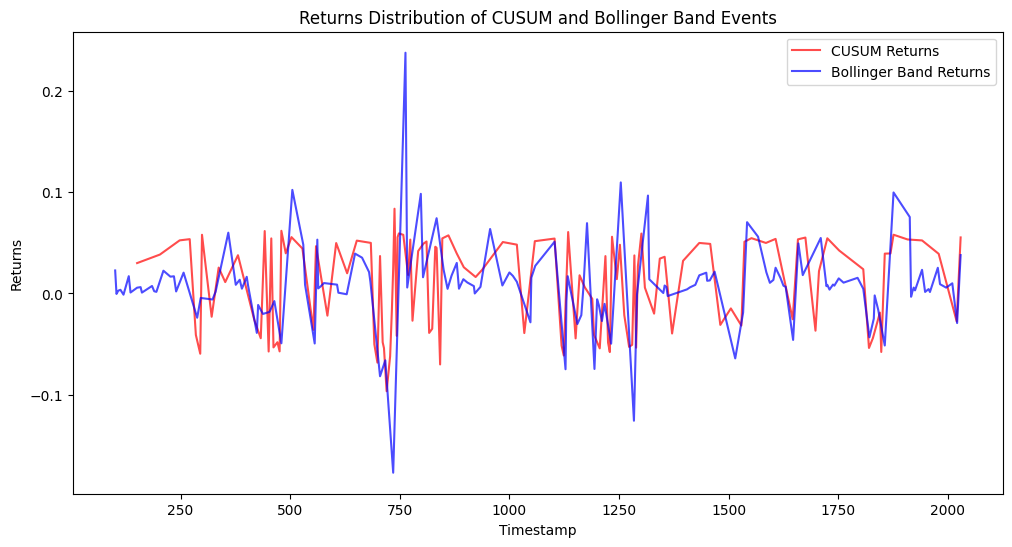

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(cusum_returns.index, cusum_returns, label='CUSUM Returns', color='red', alpha=0.7)
plt.plot(bollinger_returns.index, bollinger_returns, label='Bollinger Band Returns', color='blue', alpha=0.7)
plt.title('Returns Distribution of CUSUM and Bollinger Band Events')
plt.xlabel('Timestamp')
plt.ylabel('Returns')
plt.legend()
plt.show()